## Vægt- og Balance Analyse
#### Udarbejdet af Christian Peter Hübschmann
Bachelorprojekt på DTU i "Mekanisk Design og Teknologi" om Saab T-17 i samarbejde med Flyveskolen. \
Formålet med dette script er at udregne og visualisere tyngdepunktsplaceringen i T-17 under forskellige scenarier (piloter, brændstofmængde, etc.) og ved forskellige konfigurationer (ny motor / propel, rykning af komponenter, etc.)

In [1]:
# Relevante pakker
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
from PIL import Image
import unicodedata

In [2]:
# MAC definition og CG-envelope grænser (Fig. V.2)

# MAC-konstanter
MAC_LE_CM     = 195.0   # MAC leading edge, cm fra datum
MAC_TR_CM     = 331.0   # MAC trailing edge, cm fra datum
MAC_LENGTH_CM = 136.0  # MAC-længde, cm

# ── AFT CG-grænser i %MAC ────────────────────────────────
CG_LIMIT_AFT_NORMAL_PCT  = 30.0   # Normal kategori (≤ 1200 kg)
CG_LIMIT_AFT_UTILITY_PCT = 27.5   # Utility I, II og Aerobatic
 
# Ét lineært segment definerer hældningen (aflæst fra CG-envelope, Fig. V.2):
# 825 kg → 15% MAC,  1000 kg → 20% MAC
# Samme hældning ekstrapoleres til 1200 kg (og fastholdet på 15% MAC under 825 kg)
FRONT_KG1, FRONT_PCT1 = 825.0, 15.0
FRONT_KG2, FRONT_PCT2 = 1000.0, 20.0
FRONT_SLOPE = (FRONT_PCT2 - FRONT_PCT1) / (FRONT_KG2 - FRONT_KG1)  # %MAC per kg

def front_cg_limit(vaegt_kg: float) -> float:
    """
    Beregn den vægtspecifikke front CG-grænse i %MAC.
    Lineær ekstrapolation fra det ene aflæste segment i CG-envelope (Figure V.2, T-17-1 Flight Manual).
    Under 825 kg fastholdes 15% MAC.
    """
    if vaegt_kg <= FRONT_KG1:
        return FRONT_PCT1
    return FRONT_PCT1 + FRONT_SLOPE * (vaegt_kg - FRONT_KG1)

In [3]:
def beregn_cg(zfw_kg: float, zfw_cg_cm: float, ændringer: list) -> tuple:
    """
    Beregn ny CG efter tilføjelse/ændring af masser. Parametre:
        zfw_kg     : Zero Fuel Weight [kg]
        zfw_cg_cm  : ZFW CG-position [cm fra datum]
        ændringer  : liste af (beskrivelse, delta_masse_kg, arm_cm)
    Returnerer: (ny_vægt_kg, ny_cg_cm, cg_pct_mac)
    Enheder: kg og cm (momenter i kg·cm, konverteres til kg·m i output)
    """

    # ── ZFW moment ──
    total_moment = zfw_kg * zfw_cg_cm
    total_masse  = zfw_kg
    moment_ændring = 0
    
    print("\n" + "="*90)
    print("T-17  Vægt & Balance — CG-beregning")
    print("="*90)
    print(f"{'Komponent':<28} {'Masse [kg]':>12} {'Arm fra ZFW CG [cm]':>22} {'Moment ændring [kg·m]':>26}")
    print("-"*90)
    print(f"{'ZFW':<28} {zfw_kg:>10.1f} {'(= 0)':>20} {'(= 0)':>20}")

    for beskrivelse, dm_kg, arm_cm in ændringer:
        moment = dm_kg * arm_cm
        total_moment += moment
        total_masse  += dm_kg
        arm_fra_cg = arm_cm - zfw_cg_cm
        moment_fra_cg = dm_kg * arm_fra_cg
        moment_ændring += moment_fra_cg
        print(f"  {beskrivelse:<26} {dm_kg:>+10.1f} {arm_fra_cg:>+20.1f} {moment_fra_cg/100:>+20.1f}")

    if total_masse > 1200.0:
        print("-"*90)
        print(f"  ✗  TOTALVÆGT {total_masse:.1f} kg OVERSKRIDER MAKS. TAKEOFF WEIGHT (1200.0 kg) — BEREGNING AFBRUDT")
        print("="*90)
        return None, None, None
    
    print("-"*90)
    ny_cg_cm    = total_moment / total_masse
    ny_cg_pct   = (ny_cg_cm - MAC_LE_CM) / MAC_LENGTH_CM * 100.0

    print(f"{'NY TOTAL':<28} {total_masse:>9.1f} kg {'':>20} {moment_ændring/100:>16.1f} kg·m")
    print(f"\n  ➤  Ny CG:   {ny_cg_cm:.2f} cm fra datum")
    print(f"  ➤  CG %MAC: {ny_cg_pct:.2f}%")

    # ── CG-grænse-check ──
    fwd_limit = front_cg_limit(total_masse)
    print(f"  ➤  Fwd CG-limit ved {total_masse:.1f} kg: {fwd_limit:.2f}% MAC")
    if total_masse >= 1125.0:
        aft_limit = CG_LIMIT_AFT_NORMAL_PCT
    else:
        aft_limit = CG_LIMIT_AFT_UTILITY_PCT
    print(f"  ➤  Aft CG-limit ved {total_masse:.1f} kg: {aft_limit:.2f}% MAC")
 
    front_limit_check = ny_cg_pct < fwd_limit
    back_normal_check  = ny_cg_pct > CG_LIMIT_AFT_NORMAL_PCT
    back_utility_check = ny_cg_pct > CG_LIMIT_AFT_UTILITY_PCT
 
    if ny_cg_pct < 0:
        print(f"  ✗  CG ER FORAN MAC LEADING EDGE — UGYLDIG KONFIGURATION!")
    elif front_limit_check:
        margin = fwd_limit - ny_cg_pct
        print(f"  ⚠  CG er foran fwd-limit ({fwd_limit:.2f}% MAC) for {total_masse:.1f}kg med {margin:.2f}%MAC")
    elif back_normal_check and total_masse>=1125.0 or ny_cg_pct > CG_LIMIT_AFT_NORMAL_PCT:
        margin = ny_cg_pct - CG_LIMIT_AFT_NORMAL_PCT
        print(f"  ✗  CG OVERSKRIDER AFT LIMIT ({CG_LIMIT_AFT_NORMAL_PCT}% MAC) med {margin:.2f}%MAC")
    elif back_utility_check and total_masse<1125.0:
        margin = ny_cg_pct - CG_LIMIT_AFT_UTILITY_PCT
        print(f"  ⚠  CG er bag Utility/Aerobatic aft-limit ({CG_LIMIT_AFT_UTILITY_PCT}% MAC) med {margin:.2f}%MAC - Kan kun føres i Normal ({CG_LIMIT_AFT_NORMAL_PCT}%MAC) kategori")
    else:
        if total_masse >= 1125.0:
            margin_aft  = CG_LIMIT_AFT_NORMAL_PCT - ny_cg_pct
        else:
            margin_aft  = CG_LIMIT_AFT_UTILITY_PCT - ny_cg_pct
        margin_fwd  = ny_cg_pct - fwd_limit
        print(f"  ✓  CG er indenfor CG envelope for den beregnede totalvægt (AUW)")
        print(f"     Margin til aft-limit: {margin_aft:.2f}%MAC  |  "
              f"Margin til fwd-limit: {margin_fwd:.2f}%MAC")

    print("="*90)
    return total_masse, ny_cg_cm, ny_cg_pct

In [4]:
# Billede-kalibrering (pixel-analyse af T-17_tegning_med_MAC.png)

# Indlæs billeder (konverteret til ægte PNG ved første kørsel)
fly_img   = mpimg.imread(('T-17 tegning med MAC uden procent.png'))
cg_raw    = Image.open(('CG symbol.png')).convert("RGBA")
DATUM_PX     = 16     # x-pixel for Reference Datum (lodrette stiplede linje)
IMG_WIDTH_PX = 649    # total billedbredde i pixels
SCALE_CM     = 710.0  # cm fra datum til højre billedkant
PX_PER_CM    = (IMG_WIDTH_PX - DATUM_PX) / SCALE_CM   # ≈ 0.893 px/cm

CENTERLINE_Y_PX = 192   # y-pixel for vandret stiplede centerline (fuselage)

def cm_to_px(cm: float) -> float:
    """Konverter arm (cm fra datum) til x-pixel i billedet."""
    return DATUM_PX + cm * PX_PER_CM

In [5]:
def visualiser_cg(ny_vaegt_kg: float, ny_cg_cm: float, ny_cg_pct: float, load_case_navn: str = "Load Case"):
    """vTegner CG-symbolet på flyets sideprofil ved den beregnede CG-position. """

    img_h, img_w = fly_img.shape[:2]

    # ── Figur-opsætning ───────────────────────────────────────────────────────
    fig_width  = 14
    fig_height = fig_width * (img_h / img_w) * 1.5
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    top_margin   = 32   # ekstra pixels over flyillustrationen til info-boks
    ax.set_xlim(0, img_w)
    ax.set_ylim(0, img_h + 110 + top_margin)
    ax.set_aspect('equal')
    ax.axis('off')

    y_offset         = 100
    y_img_bottom     = y_offset
    y_img_top        = y_offset + img_h
    centerline_y_fig = y_img_top - CENTERLINE_Y_PX

    ax.imshow(fly_img, extent=[0, img_w, y_img_bottom, y_img_top], origin='upper')

    # ── Skala i bunden ────────────────────────────────────────────────────────
    scale_y  = 70
    tick_h   = 12
    major_cm = np.arange(0, SCALE_CM + 1, 100)
    minor_cm = np.arange(0, SCALE_CM + 1,  50)

    ax.hlines(scale_y, DATUM_PX, IMG_WIDTH_PX, color='#333333', lw=1.5)

    for cm in major_cm:
        px = cm_to_px(cm)
        ax.vlines(px, scale_y - tick_h/2, scale_y + tick_h/2, color='#333333', lw=2.0)
        ax.text(px, scale_y - tick_h - 4, f'{int(cm)}', ha='center', va='top', fontsize=16, color='#333333')

    for cm in minor_cm:
        if cm % 100 != 0:
            px = cm_to_px(cm)
            ax.vlines(px, scale_y - tick_h/4, scale_y + tick_h/4, color='#333333', lw=0.8)

    ax.text(img_w / 2, scale_y - tick_h - 18, 'Arm fra Reference Datum [cm]',
            ha='center', va='top', fontsize=16, color='#333333', style='italic')

    ax.text(DATUM_PX, scale_y + tick_h, 'Ref.\nDatum', ha='center', va='bottom', 
            fontsize=10, color='#555555')

    # ── MAC-markering ─────────────────────────────────────────────────────────
    mac_le_px = cm_to_px(MAC_LE_CM)
    mac_te_px = cm_to_px(MAC_TR_CM)
    mac_y     = scale_y + 32

    ax.hlines(mac_y, mac_le_px, mac_te_px, color='steelblue', lw=3.0)
    ax.annotate('', xy=(mac_te_px, mac_y), xytext=(mac_le_px, mac_y), 
                arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.5))
    ax.text((mac_le_px + mac_te_px) / 2, mac_y - 16,
            'MAC', ha='center', va='bottom', fontsize=15, color='steelblue')

    # ── Grænser for den aktuelle AUW ──────────────────────────────────────────
    fwd_limit_pct = front_cg_limit(ny_vaegt_kg)
    aft_limit_pct = CG_LIMIT_AFT_NORMAL_PCT if ny_vaegt_kg >= 1125.0 or ny_cg_pct > CG_LIMIT_AFT_NORMAL_PCT else CG_LIMIT_AFT_UTILITY_PCT

    fwd_limit_cm = MAC_LE_CM + fwd_limit_pct / 100.0 * MAC_LENGTH_CM
    aft_limit_cm = MAC_LE_CM + aft_limit_pct / 100.0 * MAC_LENGTH_CM
    fwd_limit_px = cm_to_px(fwd_limit_cm)
    aft_limit_px = cm_to_px(aft_limit_cm)

    label_y = mac_y + 18   # lige over MAC-linjen

    # Fwd limit — blå stiplet, label til VENSTRE
    ax.vlines(fwd_limit_px, scale_y, y_img_top, color='#2980b9', lw=1.4, linestyle='--', alpha=0.85)
    ax.text(fwd_limit_px - 6, label_y,
            f'Fwd: {fwd_limit_pct:.1f}%', ha='right', va='bottom', fontsize=15, 
            color='#2980b9', bbox=dict(fc='white', ec='none', pad=1))

    # Aft limit — rød stiplet, label til HØJRE
    ax.vlines(aft_limit_px, scale_y, y_img_top, color='#c0392b', lw=1.4, linestyle='--', alpha=0.85)
    ax.text(aft_limit_px + 6, label_y, f'Aft: {aft_limit_pct:.1f}%', ha='left', va='bottom', 
            fontsize=15, color='#c0392b', bbox=dict(fc='white', ec='none', pad=1))

    # ── Lower Edge of Firewall ved 120 cm ─────────────────────────────────────
    firewall_px = cm_to_px(120.0)
    ax.vlines(firewall_px, scale_y, y_img_top, color='#7f8c8d', lw=1.2, linestyle='--', alpha=0.75)
    ax.text(firewall_px - 4, scale_y + tick_h + 4, 'Lower Edge\nof Firewall\n(120cm)',
            ha='right', va='bottom', fontsize=15, color='#7f8c8d', bbox=dict(fc='white', ec='none', pad=1))

    # ── Ny CG ─────────────────────────────────────────────────────────────────
    ny_cg_px = cm_to_px(ny_cg_cm)

    foran      = ny_cg_pct < fwd_limit_pct
    bag_normal = ny_cg_pct > CG_LIMIT_AFT_NORMAL_PCT
    bag_util   = ny_cg_pct > CG_LIMIT_AFT_UTILITY_PCT and ny_vaegt_kg < 1125.0
    cg_color = '#c0392b' if (foran or bag_normal or bag_util or ny_cg_pct < 0) else '#27ae60'

    ax.vlines(ny_cg_px, scale_y, centerline_y_fig, color=cg_color, lw=2.0, linestyle='-', alpha=0.9)
    ax.plot(ny_cg_px, centerline_y_fig, 'D', color=cg_color, markersize=6, zorder=5)

    # ── CG-symbol ─────────────────────────────────────────────────────────────
    symbol_size_px_fig = 24 * PX_PER_CM * (fig_width / img_w) * 72
    cg_zoom = symbol_size_px_fig / cg_raw.size[0] * 0.55
    ab = AnnotationBbox(OffsetImage(np.array(cg_raw), zoom=cg_zoom), 
                        (ny_cg_px, centerline_y_fig), frameon=False, zorder=6)
    ax.add_artist(ab)

    # ── Tekst-output boks ─────────────────────────────────────────────────────
    margin_fwd = ny_cg_pct - fwd_limit_pct
    margin_aft = aft_limit_pct - ny_cg_pct

    if ny_cg_pct < 0:
        status = "✗ FORAN MAC LEADING EDGE — UGYLDIG"
    elif foran:
        status = f"✗ FORAN FWD LIMIT ({fwd_limit_pct:.1f}%MAC) - UGYLDIG"
    elif bag_normal:
        status = f"✗ BAG AFT LIMIT ({CG_LIMIT_AFT_NORMAL_PCT}%MAC) — UGYLDIG"
    elif bag_util:
        status = (f"⚠ Bag Utility/Aerobatic aft limit ({CG_LIMIT_AFT_UTILITY_PCT}%MAC)\n"
              f"              Kan kun føres i Normal ({CG_LIMIT_AFT_NORMAL_PCT}%MAC) kategori")
    else:
        status = f"✓ OK  (fwd margin: {margin_fwd:.2f}%  aft margin: {margin_aft:.2f}%)"
    
    info_text = (
        f"{load_case_navn}\n"
        f"AUW:          {ny_vaegt_kg:.1f} kg\n"
        f"CG:           {ny_cg_cm:.2f} cm fra datum\n"
        f"CG (%MAC):    {ny_cg_pct:.2f}%\n"
        f"Fwd limit:    {fwd_limit_pct:.2f}% MAC\n"             
        f"Aft limit:    {aft_limit_pct:.2f}% MAC\n"
        f"Status:       {status}" )
    ax.text(0.01, 0.99, info_text, transform=ax.transAxes, va='top', ha='left', fontsize=12, 
            fontfamily='monospace', bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#cccccc', alpha=0.92))

    # ── Legende ───────────────────────────────────────────────────────────────
    plt.title(f"T-17 Vægt & Balance — {load_case_navn}", fontsize=16, pad=8)
    plt.tight_layout()
    
    def _sanitize(s):
        s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
        return s.replace(' ', '_')
 
    filnavn = f"cg_output_{_sanitize(load_case_navn)}.png"
    fig.savefig(filnavn, dpi=200, bbox_inches='tight', format='png')
    print(f"\n  [Figur gemt: {filnavn}]")
    plt.show()


T-17  Vægt & Balance — CG-beregning
Komponent                      Masse [kg]    Arm fra ZFW CG [cm]      Moment ændring [kg·m]
------------------------------------------------------------------------------------------
ZFW                               733.0                (= 0)                (= 0)
  Pilot venstre sæde             +100.0                -19.0                -19.0
  Pilot højre sæde               +100.0                -19.0                -19.0
  100 LL Brændstof (10.0L)         +7.2                +42.0                 +3.0
  Afmonteret IFF system            -7.0                +73.0                 -5.1
  Afmonteret bagsæde               -5.0                +51.0                 -2.5
------------------------------------------------------------------------------------------
NY TOTAL                         928.2 kg                                 -42.6 kg·m

  ➤  Ny CG:   222.41 cm fra datum
  ➤  CG %MAC: 20.15%
  ➤  Fwd CG-limit ved 928.2 kg: 17.95% MAC
  ➤  Aft CG-l

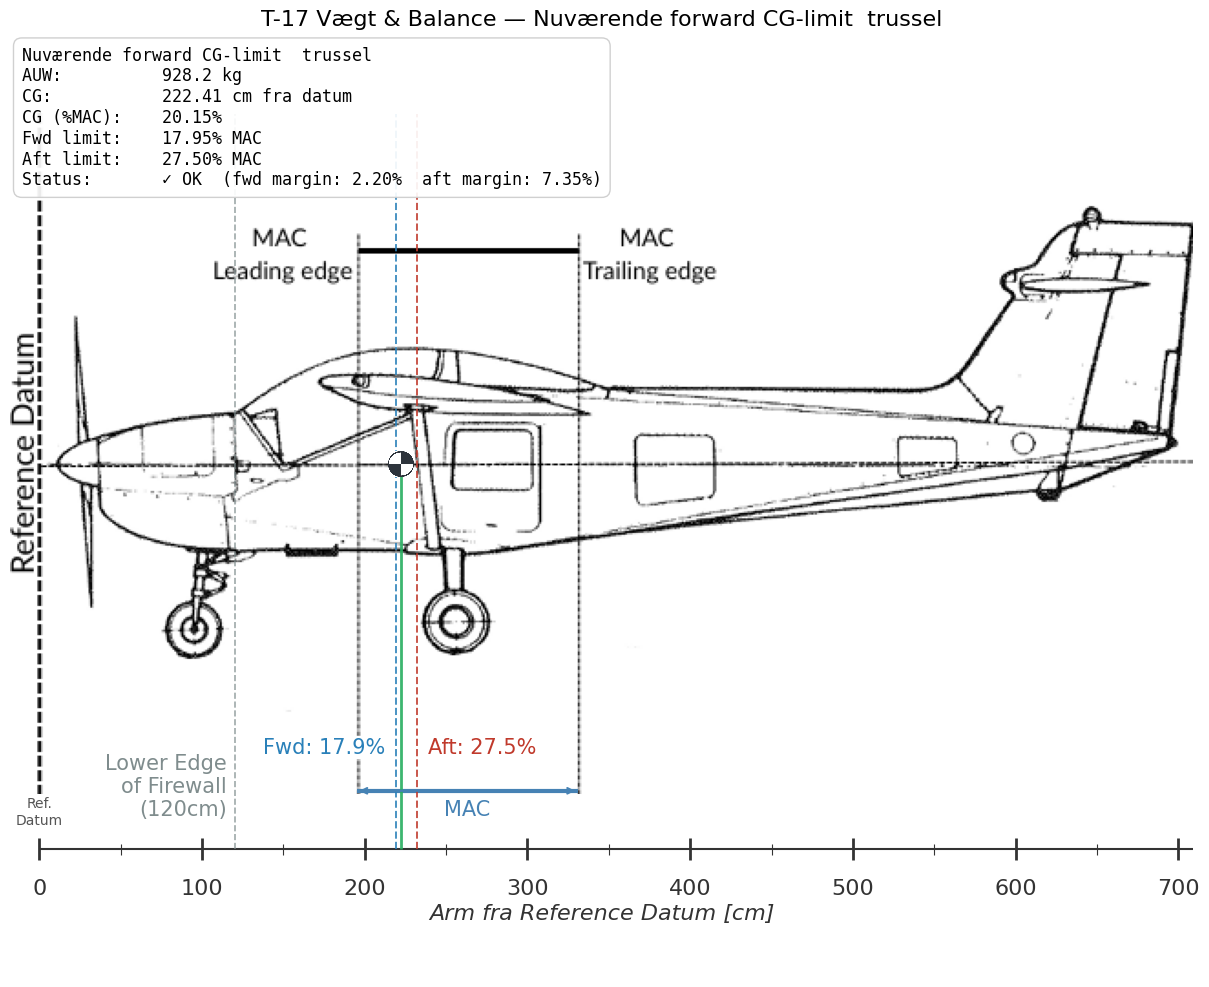

In [6]:
# ═════════════════════════════════════════════════════════
#  ▼▼▼  BRUGERINPUT  ▼▼▼
# ═════════════════════════════════════════════════════════

# ZFW-konfiguration (aflæst fra Matins vægt & balance-dokument og RDAF T-17 Flight Manual)
ZFW_KG     = 733.0    # kg (inkluderer 10L "unusable" brændstof i hver vinge og 8 quarts olie)
ZFW_CG_CM  = 227.0    # cm fra datum

# Standard arm-positioner (cm fra datum)
ARM_propel          = 25.0  # cm fra datum (antaget propel CG)
ARM_motor           = 72.0  # cm fra datum (antaget motor CG)
ARM_pilot_sæde      = 218.0 # cm fra datum (pilot sæder)
ARM_bagsæde         = 278.0 # cm fra datum (passager sæde)
ARM_cargo           = 278.0 # cm fra datum (cargo)
ARM_fuel            = 269.0 # cm fra datum (brændstof CG)
ARM_IFF             = 300.0 # cm fra datum (antaget IFF system i avionics compartment)
ARM_batteri         = 379.0 # cm fra datum (hovedbatteri i avionics compartment)
ARM_LINDA_C         = 546.0 # cm fra datum (LINDA-C i haleparti)

# Standard vægt
Bagsæde_kg      = 5.0   # kg (vægt for bagsædet)
Batteri_kg      = 13.3  # kg (vægt for hovedbatteri)
IFF_kg          = 7.0   # kg (vægt for IFF system)
DeltaHawk_dm_kg = 1.0   # kg (Vægtforskel for DeltaHawk motor vs. original Lycoming)
Propel_dm_kg    = -6.8  # kg (Vægtforskel for tre-bladet propel vs. original to-bladet)

# Omregning af brændstofvægt
F18_densitet = 0.7211  # kg/L for Avgas 100LL
F34_densitet = 0.805   # kg/L for Jet-A1 / JP-8

# ═════════════════════════════════════════════════════════
#  ▼▼▼  REDIGER KONFIGURATIONER HER  ▼▼▼
# ═════════════════════════════════════════════════════════
Fuel_F18_L = 10.0  # liter Avgas 100LL
Fuel_F34_L = 110.0  # liter Jet-A1 / JP-8
Fuel_F18_kg = Fuel_F18_L * F18_densitet
Fuel_F34_kg = Fuel_F34_L * F34_densitet

# Tilføjelser/ændringer fra ZFW konfigurationen:
# Format: (beskrivelse af ændring,              ændring af masse i kg,      arm i cm fra datum)
Ændringer = [
    ("Pilot venstre sæde",                      +100.0,                      ARM_pilot_sæde-10),
    ("Pilot højre sæde",                        +100.0,                      ARM_pilot_sæde-10),
    (f"100 LL Brændstof ({Fuel_F18_L}L)",       +Fuel_F18_kg,               ARM_fuel),
    #("DeltaHawk motor dm",                      +DeltaHawk_dm_kg,           ARM_motor),
    #("Tre-bladet propel dm",                    +Propel_dm_kg,              ARM_propel),
    #("Unusable F18 (20L) tømmes",               -20*F18_densitet,           ARM_fuel),
    #("Unusable F34 (20L) fyldes",               +20*F34_densitet,           ARM_fuel), 
    #(f"Jet A-1 Brændstof ({Fuel_F34_L}L)",      +Fuel_F34_kg,               ARM_fuel), 
    ("Afmonteret IFF system",                   -IFF_kg,                    ARM_IFF),
    ("Afmonteret bagsæde",                      -Bagsæde_kg,                ARM_bagsæde), 
    #("Afmonteret hovebatteri",                  -13.3,                      ARM_batteri),
    #("Hovedbatteri i halesektion",              +13.3,                      ARM_LINDA_C),
    #("Cargo",                                   +100,                       ARM_cargo),
    #("Passager",                                +75,                        ARM_bagsæde),

]
LOAD_CASE = "Nuværende forward CG-limit  trussel" # Load case navn (bruges i figur-titel og filnavn)

# ═════════════════════════════════════════════════════════
#  KØR BEREGNING OG VISUALISERING
# ═════════════════════════════════════════════════════════
ny_vaegt, ny_cg, ny_cg_pct = beregn_cg(ZFW_KG, ZFW_CG_CM, Ændringer)
if ny_vaegt is not None:
    visualiser_cg(ny_vaegt, ny_cg, ny_cg_pct, LOAD_CASE)